# TinyML - Bayesian Neural Networks

**Author:** Thommas Kevin Sales Flores  

**Institution:** Federal University of Rio Grande do Norte

**Email:** thommas.flores.101@ufrn.edu.br

## Environment Setup

The following commands install the required Python packages. They are commented out by default because the environment may already be configured. If you are running this notebook for the first time, uncomment and execute them to install:

## 1. Setup and Imports

Install required packages if not already present.

In [1]:
#!pip install -r requirements.txt

In [2]:
import sys
sys.path.append("32_BNN")
import torch
import torch.nn as nn
import torch.optim as optim
import os
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
from model import BayesianModel
from layers import BayesianLinear
from vi import *
from utils import export_to_json, elbo_loss, plot_decision_boundary, plot_regression_uncertainty
from cpp_generator import generate_ino

## 1. Regression Example: 1D Sine with a Gap

We train a BNN to predict `y = sin(x)` but only provide training data in the intervals `[-4, -1.5]` and `[1.5, 4]`. The model should exhibit **high uncertainty** in the gap `(-1.5, 1.5)` where no data is available.

This demonstrates one of the key benefits of BNNs: they can tell you what they don't know.

Starting 1D Regression Training...
X_train: tensor([-4.])
y_train: tensor([0.9495])
X_test: tensor([-5.])
y_test: tensor([0.9589])


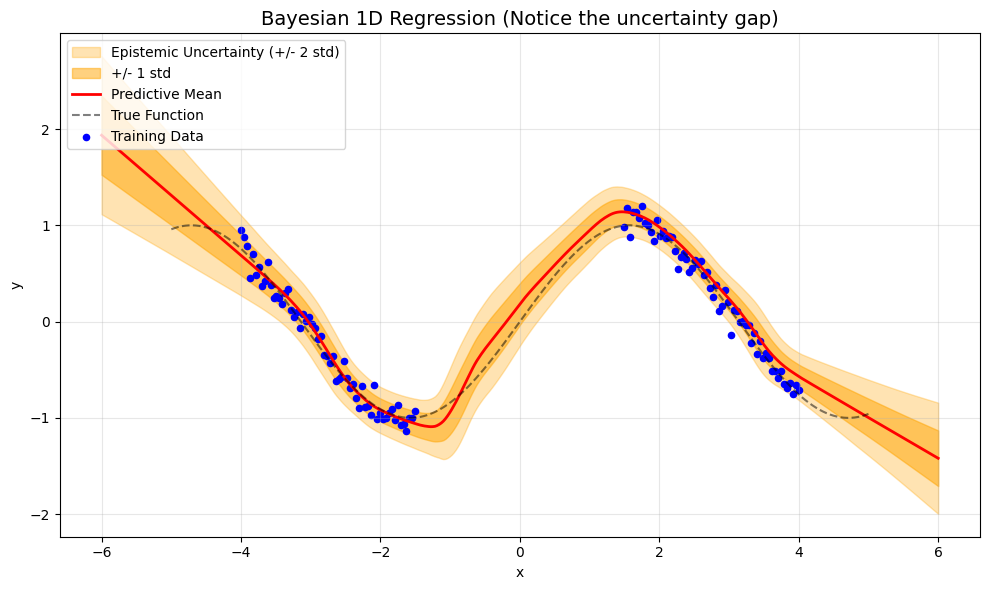

Arduino files generated in: arduino_code/regression_ino for board: esp32
Regression Arduino project generated in 'arduino_code/regression_ino' folder.



In [ ]:
def train_regression_educational():
    print("Starting 1D Regression Training...")
    torch.manual_seed(42)
    
    x_train_1 = torch.linspace(-4, -1.5, 60)
    x_train_2 = torch.linspace(1.5, 4, 60)
    X_train = torch.cat([x_train_1, x_train_2]).view(-1, 1)
    y_train = torch.sin(X_train) + 0.1 * torch.randn_like(X_train)
    
    X_test = torch.linspace(-5, 5, 200).view(-1, 1)
    y_test = torch.sin(X_test)

    print("X_train:", X_train[0])
    print("y_train:", y_train[0])
    print("X_test:", X_test[0])
    print("y_test:", y_test[0])

    model = BayesianModel([
        BayesianLinear(1, 64),
        nn.ReLU(),
        BayesianLinear(64, 64),
        nn.ReLU(),
        BayesianLinear(64, 1)
    ])

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(1500):
        optimizer.zero_grad()
        output = model(X_train)
        kl_weight = 1.0 / X_train.size(0) 
        loss = elbo_loss(output, y_train, model, kl_weight=kl_weight, likelihood='regression')
        
        loss.backward()
        optimizer.step()

    plot_regression_uncertainty(model, X_train, y_train, X_test, y_test, 
                                title="Bayesian 1D Regression (Notice the uncertainty gap)")
    
    # Export and generate Arduino code
    export_to_json(model, 'json_model/regression_model.json')
    generate_ino('json_model/regression_model.json', 'arduino_code/regression_ino', board='esp32', task='regression', quantize=False)
    print("Regression Arduino project generated in 'arduino_code/regression_ino' folder.\n")
    return model


    
   
model_reg = train_regression_educational()

## 2. Binary Classification: Moon Dataset

We now train a BNN on the classic two‑moon dataset. The decision boundary will be smooth and the model will output a probability between 0 and 1.

Starting Binary Classification Training...
X_train: [ 1.5184023  -0.55922781]
y_train: 1
X_test: [ 0.50799168 -0.34745972]
y_test: 1


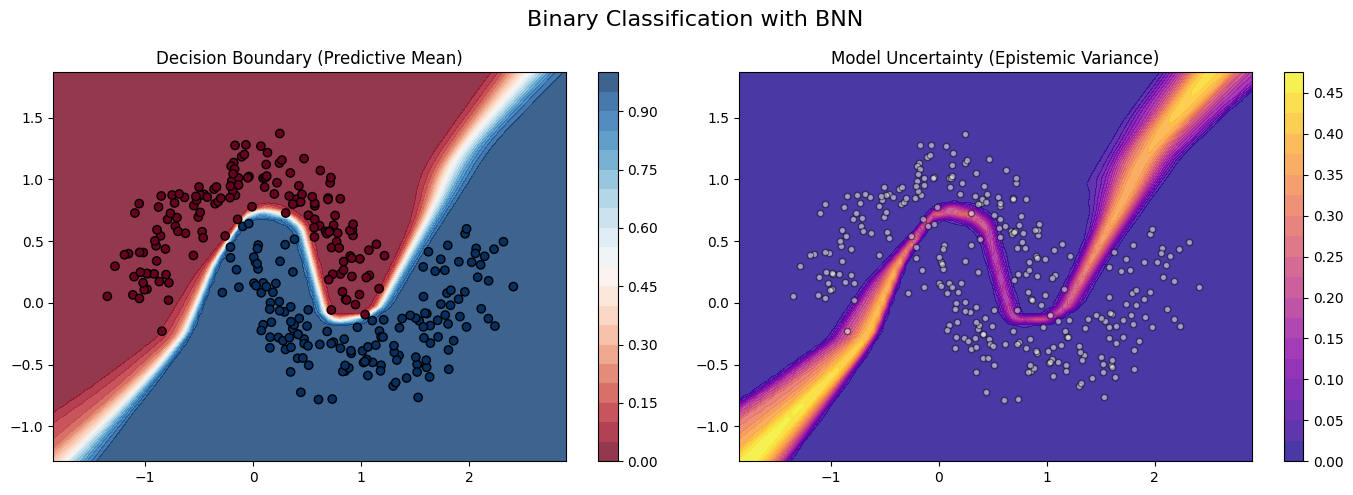

Arduino files generated in: arduino_code/binary_ino for board: esp32
Binary Arduino project generated in 'binary_ino' folder.



In [3]:
def train_binary():
    print("Starting Binary Classification Training...")
    X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).view(-1, 1)

    print("X_train:", X_train[0])
    print("y_train:", y_train[0])
    print("X_test:", X_test[0])
    print("y_test:", y_test[0])

    model = BayesianModel([
        BayesianLinear(2, 20),
        nn.ReLU(),
        BayesianLinear(20, 20),
        nn.ReLU(),
        BayesianLinear(20, 1)
    ])

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(1000):
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = elbo_loss(output, y_train_t, model, kl_weight=0.01, likelihood='binary')
        loss.backward()
        optimizer.step()

    plot_decision_boundary(model, X, y, title="Binary Classification with BNN", task='binary')
    
    # Export and generate Arduino code
    export_to_json(model, 'json_model/binary_model.json')
    generate_ino('json_model/binary_model.json', 'arduino_code/binary_ino', board='esp32', task='binary', quantize=False)
    print("Binary Arduino project generated in 'binary_ino' folder.\n")
    return model


model_bin = train_binary()

## 3. Multiclass Classification: Blobs Dataset

For more than two classes, the final layer outputs logits for each class, and we use the categorical likelihood (cross‑entropy).

Starting Multiclass Classification Training...
X_train: [-2.62485019  9.52601409]
y_train: 0
X_test: [3.0840096  1.68766167]
y_test: 1


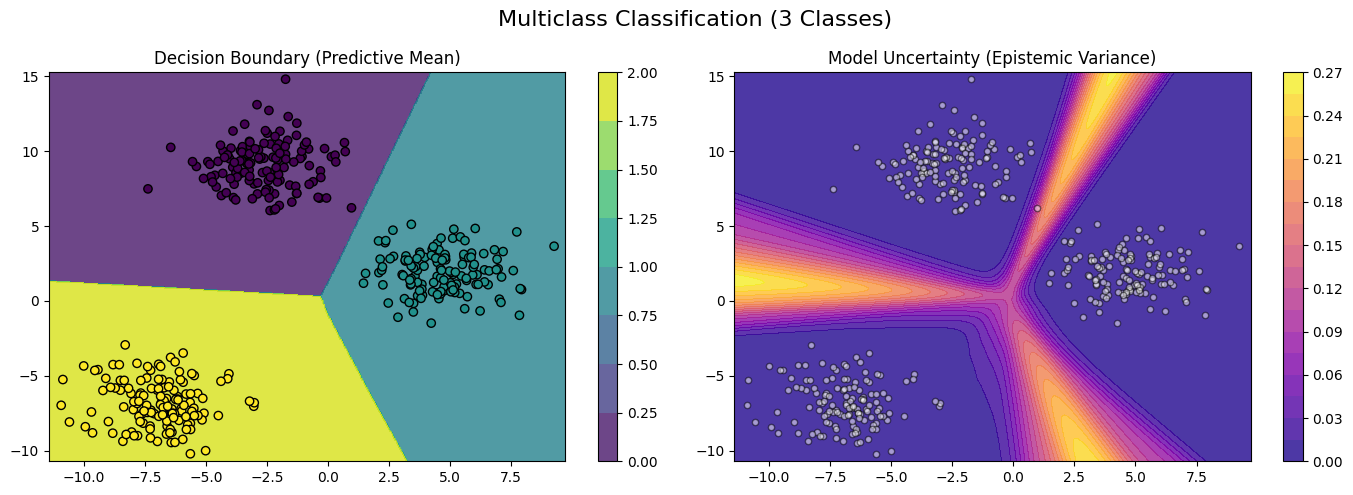

Arduino files generated in: arduino_code/multiclass_ino for board: esp32
Multiclass Arduino project generated in 'arduino_code/multiclass_ino' folder.



In [4]:
def train_multiclass():
    print("Starting Multiclass Classification Training...")
    X, y = make_blobs(n_samples=400, centers=3, cluster_std=1.5, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.LongTensor(y_train)
    print("X_train:", X_train[0])
    print("y_train:", y_train[0])
    print("X_test:", X_test[0])
    print("y_test:", y_test[0])

    model = BayesianModel([
        BayesianLinear(2, 30),
        nn.ReLU(),
        BayesianLinear(30, 3)
    ])

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(1000):
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = elbo_loss(output, y_train_t, model, kl_weight=0.01, likelihood='classification')
        loss.backward()
        optimizer.step()

    plot_decision_boundary(model, X, y, title="Multiclass Classification (3 Classes)", task='multiclass')
    
    # Export and generate Arduino code
    export_to_json(model, 'json_model/multiclass_model.json')
    generate_ino('json_model/multiclass_model.json', 'arduino_code/multiclass_ino', board='esp32', task='multiclass', quantize=False)
    print("Multiclass Arduino project generated in 'arduino_code/multiclass_ino' folder.\n")
    return model

model_multi = train_multiclass()